<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
     Online Retail Customer Segmentation Using K-Means

</center></p></h1>

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Table Content  
</center></p></h1>

-<ul>
  <li><a href="#1">1. Introduction</a></li>

  <li><a href="#2">2. Data Understanding and Preprocessing</a>
    <ul>
      <li><a href="#2.1">2.1. Importing Libraries</a></li>
      <li><a href="#2.2">2.2. Loading Dataset</a></li>
      <li><a href="#2.3">2.3. Basic Understanding Data</a></li>
      <li><a href="#2.4">2.4. Exploratory Data Analysis (EDA)</a></li>
      <li><a href="#2.5">2.5. Pairplot- correlations between all features</a></li>
      <li><a href="#2.6">2.6. Correlation</a></li>
      <li><a href="#2.7">2.7. Remove Outliers</a></li>
      <li><a href="#2.8">2.8. Handling Missing Values</a></li>
      <li><a href="#2.9">2.9. Feature Engineering (RFM Calculation)</a></li>
      <li><a href="#2.10">2.10. X/Splite Data</a></li>
      <li><a href="#2.11">2.11. Data Normalization</a></li>
      <li><a href="#2.12">2.12. PCA Perform</a></li>
    </ul>
  </li>

  <li><a href="#3">3. Customer Segmentation Using K-Means</a>
    <ul>
      <li><a href="#3.1">3.1. Hopkins Test </a></li>
      <li><a href="#3.2">3.2. Elbow Method (WCSS Plot)</a></li>
      <li><a href="#3.4">3.4. Applying K-Means Clustering</a></li>
    </ul>
  </li>

  <li><a href="#4">4. Visualization and Insights</a>
  <li><a href="#7">5. Conclusion and Analysis of Customer Segmentation</a></li>
</ul>



<a id="1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     1. Introduction
</center></p></h1>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    <p style="color: green; font-weight: bold; font-size: 16px;">
        Project Overview:
    </p>
    <ul>
        <li>
            This project showcases <b>customer segmentation</b> in retail using <b>unsupervised learning</b>
            with the <b>K-Means clustering</b> algorithm to uncover meaningful customer patterns.
        </li>
        <li>
            The data is carefully <b>preprocessed</b>, missing values are handled, and <b>RFM (Recency, Frequency, Monetary)</b>
            features are engineered to effectively represent customer purchasing behavior.
        </li>
        <li>
            The K-Means model organizes customers into <b>distinct segments</b>, enabling businesses to
            implement <b>targeted marketing strategies</b> and identify high-value or at-risk customers.
        </li>
        <li>
            By leveraging these insights, businesses can <b>enhance customer retention</b> and
            <b>increase sales</b> through <b>personalized engagement</b> and data-driven decisions.
        </li>
    </ul>
</div>


<a id="2"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2. Data Understanding
</center></p></h1>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    <p style="color: green; font-weight: bold; font-size: 16px;">
        Data Understanding and Preprocessing:
    </p>
    <ul>
        <li>
            The dataset contains online retail transactional data, including <b>InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID</b>, and <b>Country</b>.
        </li>
        <li>
            Data cleaning is performed by removing <b>null entries</b>, <b>negative or zero values</b> in Quantity and UnitPrice, and <b>duplicate records</b>.
        </li>
        <li>
            Feature engineering is applied to calculate <b>TotalAmount</b> from Quantity and UnitPrice, capturing the monetary value of each transaction.
        </li>
        <li>
            The <b>InvoiceDate</b> is converted to datetime format, and a <b>reference date</b> is established to calculate recency.
        </li>
        <li>
            Data is grouped by <b>CustomerID</b> to compute <b>Recency</b>, <b>Frequency</b>, and <b>Monetary</b> metrics, forming the foundation for RFM analysis.
        </li>
    </ul>
</div>


<a id="2.1"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.1. Libraries
</center></p></h1>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler, RobustScaler,MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  calinski_harabasz_score, davies_bouldin_score

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

<a id="2.2"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      2.2.Data Loading  
</center></p></h1>

In [ ]:
df=pd.read_excel('Online Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<a id="2.3"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.3. Basic Understanding Data  
</center></p></h1>

###  Checking Dimensions of the Data.

In [4]:
df.shape

(541909, 8)

In [5]:
# the number of rows and columns in train dataset 
rows , columns = df.shape 
print ("The number of rows in train dataset : " , rows)
print ("The number of columns in train dataset : " , columns)

The number of rows in train dataset :  541909
The number of columns in train dataset :  8


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>This dataset includes the details of <b>541909> samples</li>
        <li>The number of features for the dataframe is equal to <b>8</b></li>
    </ul></div>

###  Checking the basic information of dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


###  Checking NaN values in our Dataset.

In [7]:
df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})

,Total No. of Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
print("Duplicate Values =",df.duplicated().sum())

Duplicate Values = 5268


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>From the above output we can say that there is <b>0</b> </li>
    </ul></div>

###  Showing Only Categorical & Numerical Features.

In [9]:
df.dtypes 

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [10]:
df.select_dtypes(exclude="object").head()

,Quantity,InvoiceDate,UnitPrice,CustomerID
0,6,2010-12-01 08:26:00,2.55,17850.0
1,6,2010-12-01 08:26:00,3.39,17850.0
2,8,2010-12-01 08:26:00,2.75,17850.0
3,6,2010-12-01 08:26:00,3.39,17850.0
4,6,2010-12-01 08:26:00,3.39,17850.0


In [11]:
df.dtypes[df.dtypes == 'object']

InvoiceNo      object
StockCode      object
Description    object
Country        object
dtype: object

<h1 id ="import_lib" ></a> Descriptive Statistics Analysis</h1>

In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color:rgb(20, 1, 1);">
     Since the means are larger than the standard deviations, there is likely no significant risk of outliers.
     </p>
</div>

<a id="2.4"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.4. Exploratory Data Analysis (EDA)
</center></p></h1>

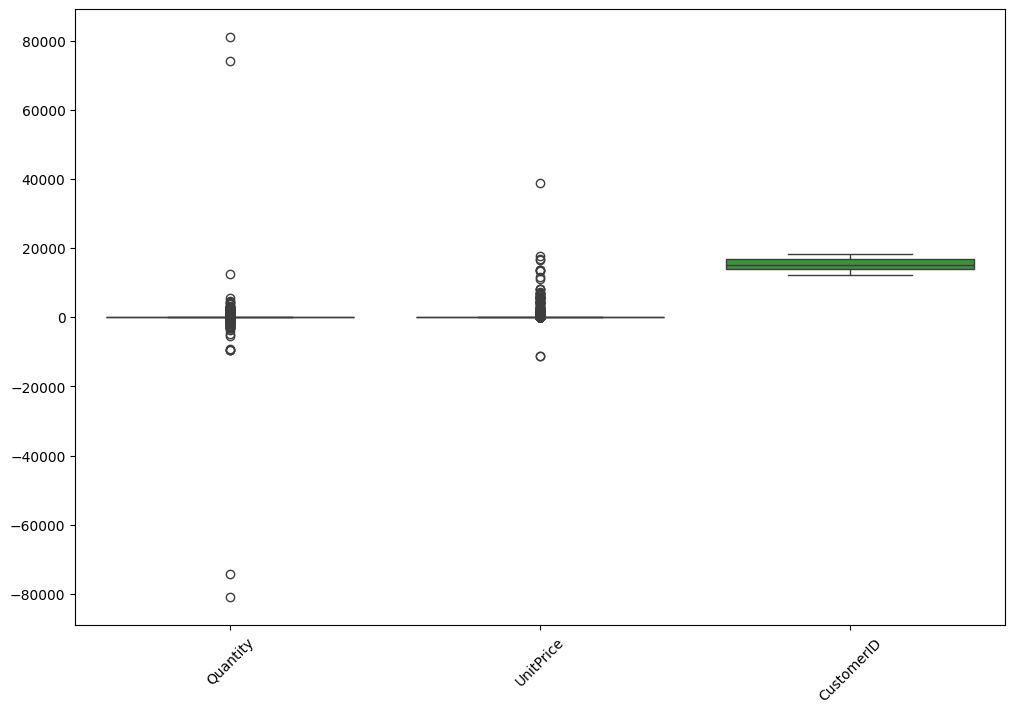

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [14]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [4]:
df.rename(columns = { "UnitPrice":"Unit_Price",  "StockCode": "Stock Code",
            }, inplace = True)

In [5]:
df.head()

,InvoiceNo,Stock Code,Description,Quantity,InvoiceDate,Unit_Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
df[df["Quantity"] == 6]

,InvoiceNo,Stock Code,Description,Quantity,InvoiceDate,Unit_Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541829,581579,22083,PAPER CHAIN KIT RETROSPOT,6,2011-12-09 12:19:00,2.95,17581.0,United Kingdom
541860,581581,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-09 12:20:00,2.89,17581.0,United Kingdom
541861,581581,23561,SET OF 6 RIBBONS PARTY,6,2011-12-09 12:20:00,2.89,17581.0,United Kingdom
541863,581582,23552,BICYCLE PUNCTURE REPAIR KIT,6,2011-12-09 12:21:00,2.08,17581.0,United Kingdom


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">Individuals with an income of 137 are predominantly male.</p>
     
<p style="font-weight: bold; color:rgb(0, 5, 2);">
         Furthermore, their incomes are generally above the overall average. Among male customers specifically, these incomes are significantly higher.
     </p>
</div>

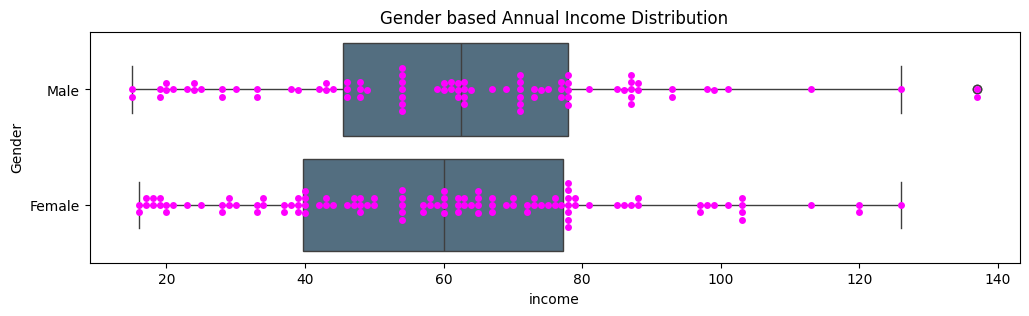

In [42]:
plt.figure(figsize=(12, 3))
sns.swarmplot(x='income', y='Gender', data=df, color="magenta")
sns.boxplot(x='income', y='Gender', data=df, saturation=0.3)
plt.title('Gender based Annual Income Distribution')
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">When examining spending scores based on gender, it is evident that there is significant overlap in many areas, with some instances where females exhibit high scores.</p>
</div>

In [ ]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

Quantity - Skewness: -0.26, Kurtosis: 119769.16
Unit_Price - Skewness: 186.51, Kurtosis: 59005.72
CustomerID - Skewness: 0.03, Kurtosis: -1.18


<a id="2.5"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">  2.5.Pairplot- correlations between all features.</p>
</div>

In [ ]:
sns.pairplot(df, palette="bright" )
plt.show()

<a id="2.6"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 2.6. Correlation between independent variable and dependent variable </p>

<Axes: >

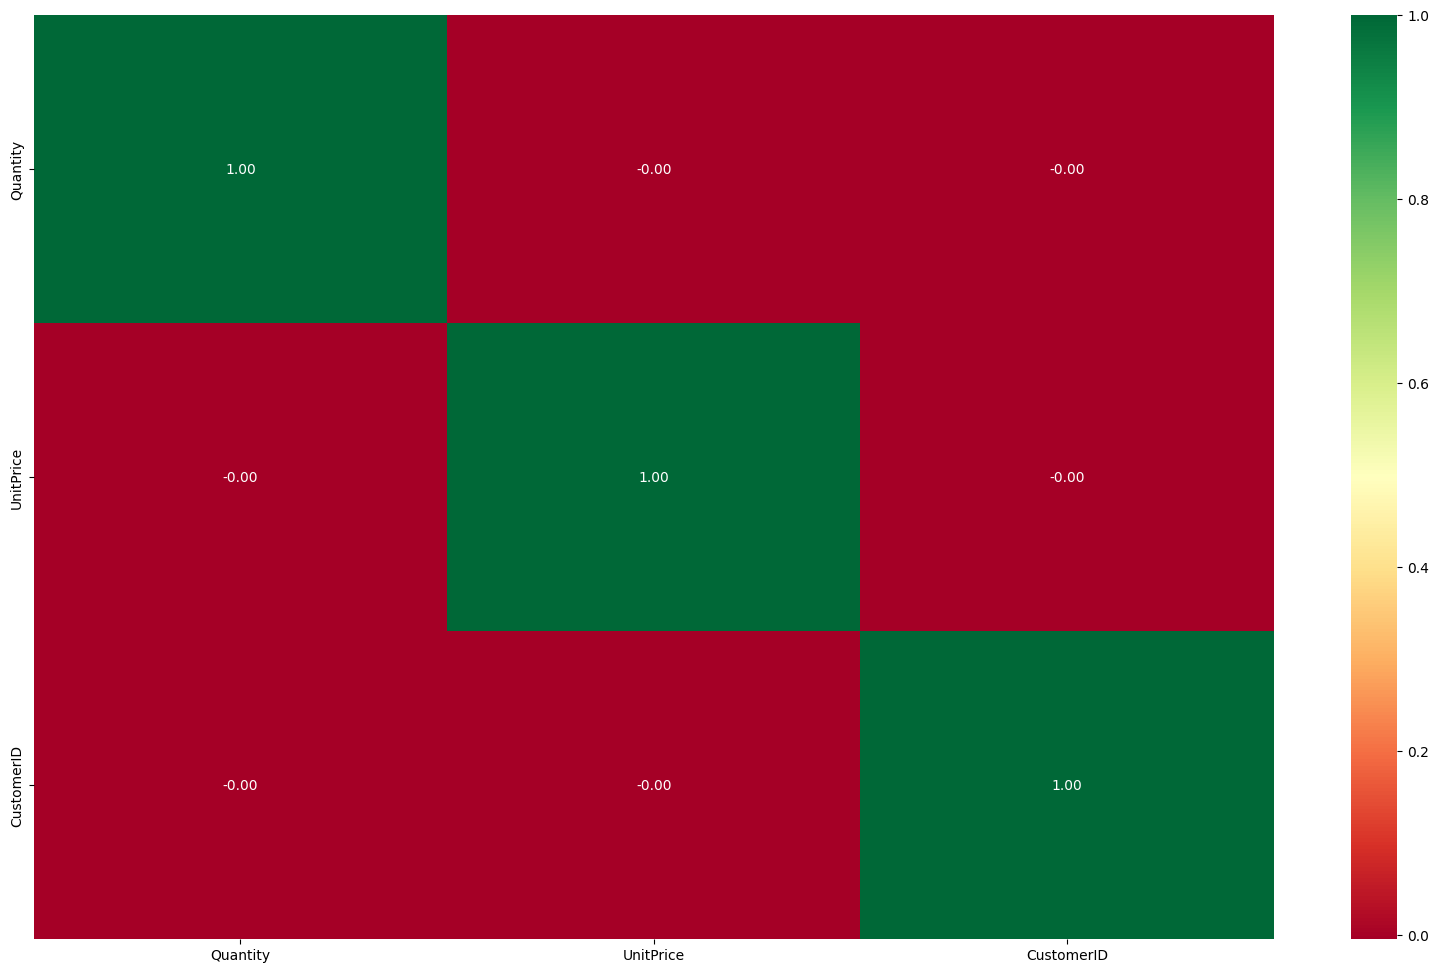

In [5]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn')

<a id="2.7"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">2.7 Remove Outliers</p>
</div>

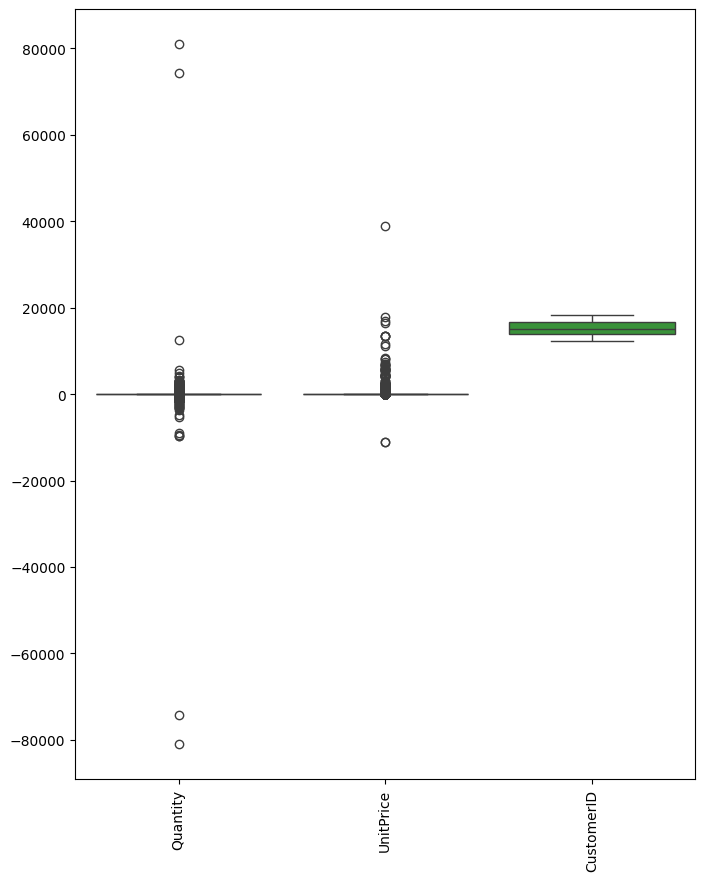

In [6]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

<a id="2.8"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 2.8. Missing Data</p>
</div>

## Missing data

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Detection missing values
print(f"The number of missing values in dataset : \n{df.isnull().sum()} " )

The number of missing values in dataset : 
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64 


In [8]:
df = df.dropna(subset=['CustomerID'])

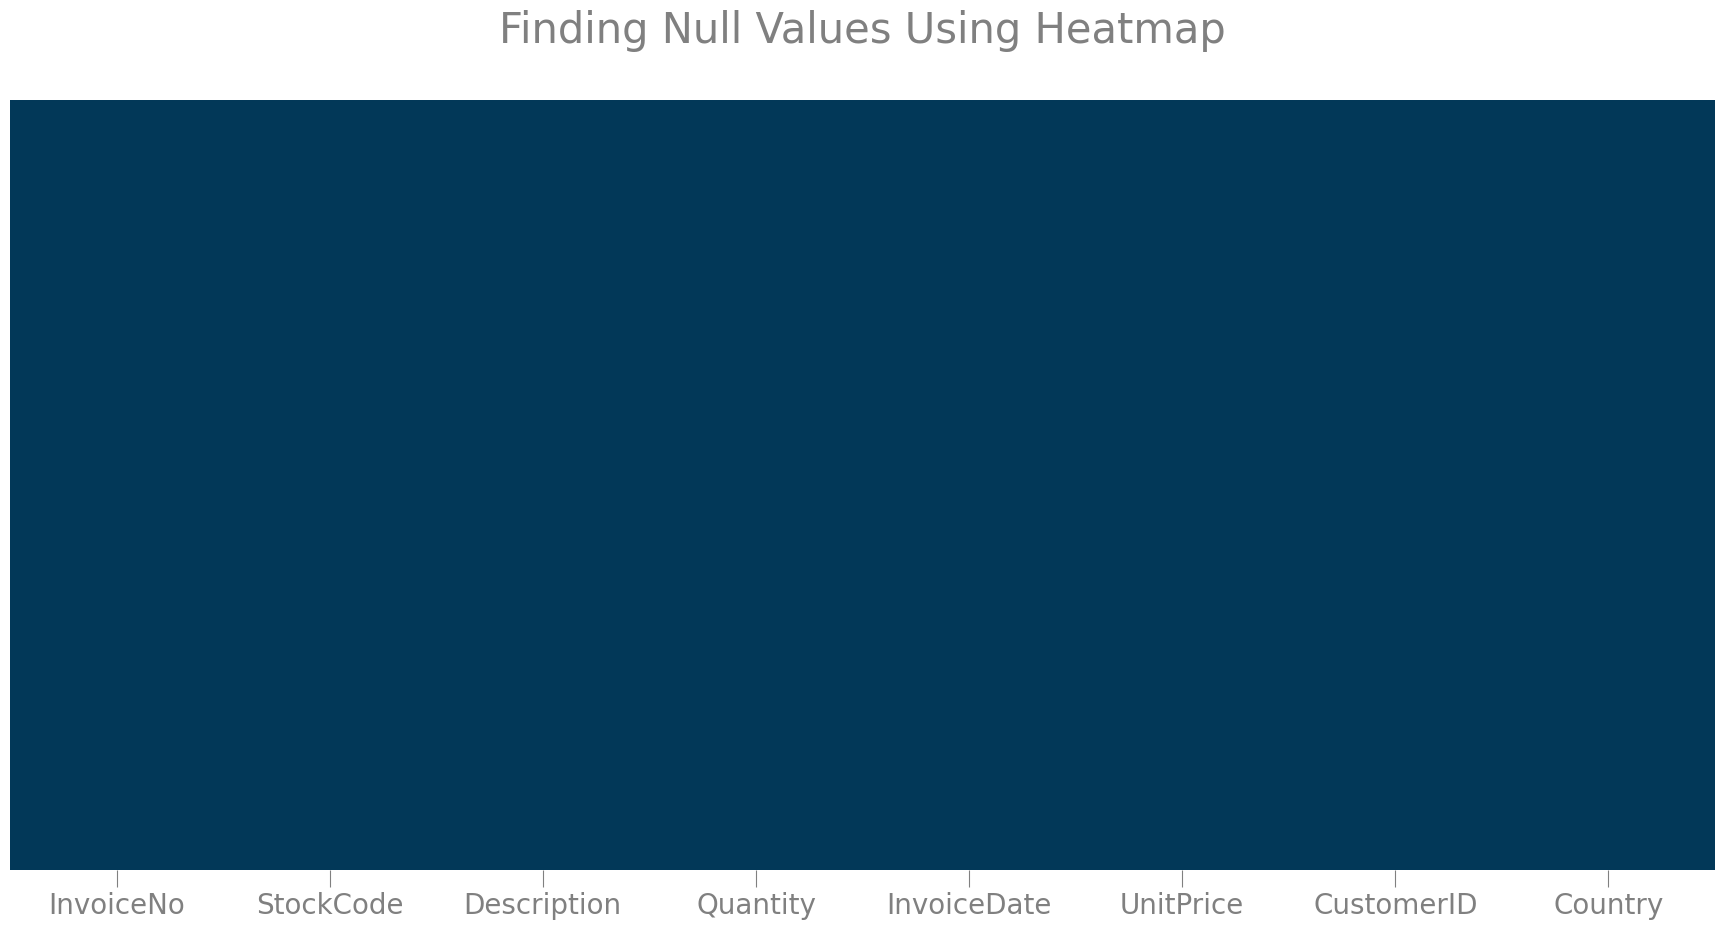

In [10]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<a id="2.9"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      2.9. Featuring 
</div>
</center></p></h1>

In [11]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


<a id="2.10"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     2.10. Data split
</div>
</center></p></h1>

In [12]:
# Data preprocessing
# Select features for clustering (Age, Annual Income, Spending Score)
X = df[['Quantity','UnitPrice']]



<a id="2.11"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    2.11. Scalling and onhotencoding
</div>
</center></p></h1>

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<a id="2.12"></a>
<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
       2.12.PCA & Scaling the DataFrame
</div>
</center></p></h1>

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca ,columns=["PCA1","PCA2"])
pca_df

,PCA1,PCA2
0,-0.007946,-0.026522
1,-0.016515,-0.017953
2,-0.004300,-0.018795
3,-0.016515,-0.017953
4,-0.016515,-0.017953
...,...,...
406824,0.026456,-0.026805
406825,-0.003355,-0.031113
406826,-0.029955,-0.015887
406827,-0.029955,-0.015887


In [15]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.50061886 0.49938114]
Total explained variance: 0.9999999999999998


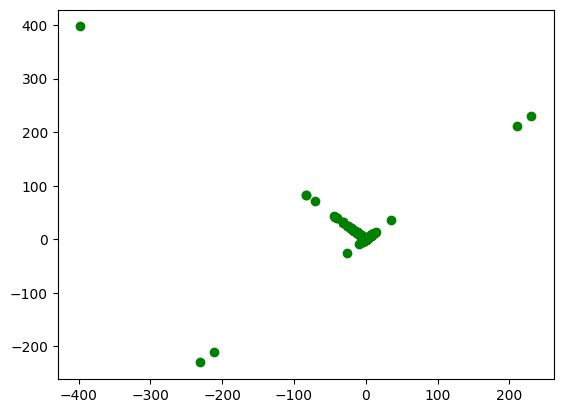

In [21]:
plt.scatter(pca_df['PCA1'],pca_df['PCA2'], color="green")
plt.show()

<a id="3"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">3. Customer Segmentation Using K-Means</p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
 <p style="color: green; font-weight: bold; font-size: 16px;">
        K-Means Clustering (Elbow Method + Model Training):
    </p>

<ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            To determine the optimal number of clusters, the <b>Within-Cluster Sum of Squares (WCSS)</b> is computed for different values of <b>k</b> using the <b>Elbow Method</b>.
        </li>
        <li>
            The <b>WCSS vs. k</b> plot helps identify the <b>elbow point</b>, which represents a suitable balance between model complexity and clustering performance.
        </li>
        <li>
            Based on the elbow curve, <b>K-Means clustering</b> is applied using the selected number of clusters (e.g., <b>k = 5</b>).
        </li>
        <li>
            The trained K-Means model assigns each customer to a segment, and the cluster labels are stored in a new column named <b>'Cluster'</b> in the RFM dataframe.
        </li>
        <li>
            Finally, cluster sizes are inspected to ensure a reasonable distribution of customers across segments.
        </li>
    </ul>

</div>


![unsupervised](https://databasetown.com/wp-content/uploads/2023/05/Unsupervised-Learning.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fdatabasetown.com%2Funsupervised-learning-types-applications%2F&psig=AOvVaw3OLEBemfakkkUbjtWyb8lc&ust=1700405736787000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiw_5HnzYIDFQAAAAAdAAAAABAD)

![kmeans](https://editor.analyticsvidhya.com/uploads/56854k%20means%20clustering.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.analyticsvidhya.com%2Fblog%2F2020%2F10%2Fa-simple-explanation-of-k-means-clustering%2F&psig=AOvVaw3cw8LOufDptpormaHu5Bcf&ust=1700398969640000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCMiF9P7NzYIDFQAAAAAdAAAAABAD)

<a id="3.1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.1.Hopkins Test </p>
</div>

![hopkins](https://i.ytimg.com/vi/E2VAV9eUh1o/maxresdefault.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DE2VAV9eUh1o&psig=AOvVaw1dz6u4Y1-sliRNvZ5Z9V58&ust=1700399141138000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiHk83OzYIDFQAAAAAdAAAAABAD)
hopkins : A statistical method that measures data clustering tendency.
More than 0.5 is prone to clustering.

In [ ]:

def hopkins(X, sampling_size=0.3):
    """Calculate Hopkins statistic for cluster tendency"""
    X = StandardScaler().fit_transform(X.values) if hasattr(X, 'values') else StandardScaler().fit_transform(X)
    n = X.shape[0]
    d = X.shape[1]
    m = int(sampling_size * n)
    
    # Uniform random samples
    uniform_samples = uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    
    # Random existing samples
    random_indices = sample(range(n), m)
    data_samples = X[random_indices]
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)  # n_neighbors=2 to skip self
    
    # Distances for uniform samples
    u_distances, _ = nbrs.kneighbors(uniform_samples, n_neighbors=1)
    
    # Distances for data samples (skip self)
    w_distances, _ = nbrs.kneighbors(data_samples, n_neighbors=2)
    w_distances = w_distances[:, 1]  # distance to nearest neighbor
    
    H = np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances))
    return H

# Calculate Hopkins statistic
hopkins_stat = hopkins(X)
print(f"Hopkins Statistic: {hopkins_stat:.3f}")

Hopkins Statistic: 1.000


<a id="3.2"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.2.Choosing The Optimal Number of Clusters-Elbow Method  </p>
</div>

![elbow](https://miro.medium.com/v2/resize:fit:1340/1*RnvrdhlUxHWss3vOffHT5g.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fmedium.com%2Fmlearning-ai%2Felbow-method-vs-silhouette-co-efficient-in-determining-the-number-of-clusters-33baff2fbeee&psig=AOvVaw13SYCkS-Yd2NZS_TZHA0B1&ust=1700399312464000&source=images&cd=vfe&opi=89978449&ved=0CBMQjhxqFwoTCLjasZvPzYIDFQAAAAAdAAAAABAI)

In [32]:
K_range = range(2, 11)   # 2..10  => 9 values
inertias = []            # RESET


In [33]:
# ---------- Elbow Method (WCSS / Inertia) ----------

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)   # یا X_pca
    inertias.append(kmeans.inertia_)

print("len(K_range):", len(list(K_range)))
print("len(inertias):", len(inertias))




len(K_range): 9
len(inertias): 9


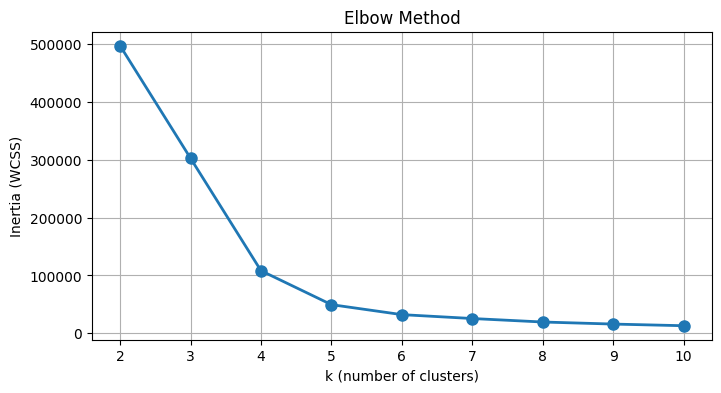

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o", linewidth=2, markersize=8)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color: black;">An elbow is observed at 2 and 4, indicating a point of inflection. According to the elbow graph, selecting a higher number of clusters increases complexity. Therefore, it is more suitable to choose 4 clusters in this case.</p>
</div>

<a id="3.4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.4. Applying K-Means Clustering
</p>
</div>

In [38]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Add cluster labels to original df
df['Cluster'] = labels

<a id="3.3"><a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 3.3.Silhouette Analysis</p>
</div>

In [ ]:
score = silhouette_score(X_pca, labels)
print(f"For n_clusters={k}, the silhouette score is {score}")

<a id="4"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">4. Visualization and Insights </p>
</div>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    
<p style="color: green; font-weight: bold; font-size: 16px;">
        Visualization and Insights:
    </p>

 <ul style="font-size: 18px; font-family: 'Arial'; line-height: 1.5em;">
        <li>
            <b>Pairplot:</b> Visualizes relationships between the <b>scaled RFM features</b> colored by cluster labels,
            helping observe how well clusters separate across <b>Recency</b>, <b>Frequency</b>, and <b>Monetary</b>.
        </li>
        <li>
            <b>Scatter Plot (Recency vs. Monetary):</b> Displays customer segments using <b>Recency</b> and <b>Monetary</b> values,
            where different colors represent cluster assignments.
        </li>
        <li>
            <b>Customer Segments by PCA:</b> Applies <b>Principal Component Analysis (PCA)</b> to reduce the scaled RFM features into
            <b>two principal components</b>, enabling a clearer 2D visualization of cluster separation.
        </li>
        <li>
            <b>Cluster Profiling:</b> Summarizes customer segments by reporting the <b>average Recency, Frequency, and Monetary</b>
            values per cluster, supporting interpretation of each segment’s behavior and characteristics.
        </li>
    </ul>

</div>


In [41]:
df['Cluster'].value_counts()

Cluster
0    406827
1         2
Name: count, dtype: int64

In [42]:
cluster_summary = df.groupby('Cluster')[['Quantity','UnitPrice']].mean()
print("\nCluster Summary (mean values):")
print(cluster_summary)


Cluster Summary (mean values):
             Quantity  UnitPrice
Cluster                         
0           12.442876    3.46048
1       -77605.000000    1.56000


Text(0.5, 1.0, 'Distribution of clusters')

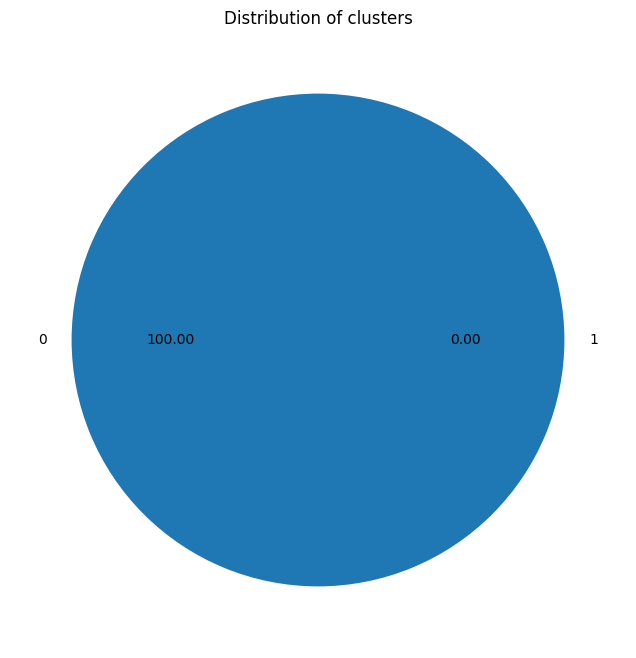

In [43]:
df['Cluster'].value_counts().plot(kind="pie", autopct='%.2f', figsize=[8,8], label="")
plt.title('Distribution of clusters')

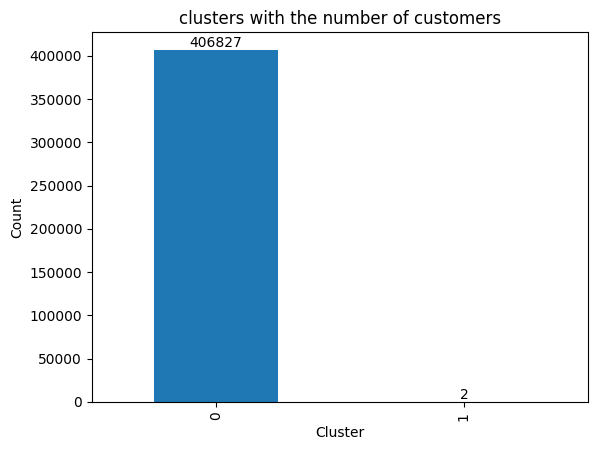

In [44]:
plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = df['Cluster'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>It is observed that the highest number of individuals is in Cluster 0, while the lowest number is in Cluster 2.</li>
    </ul>
</div>

<Figure size 2000x1000 with 0 Axes>

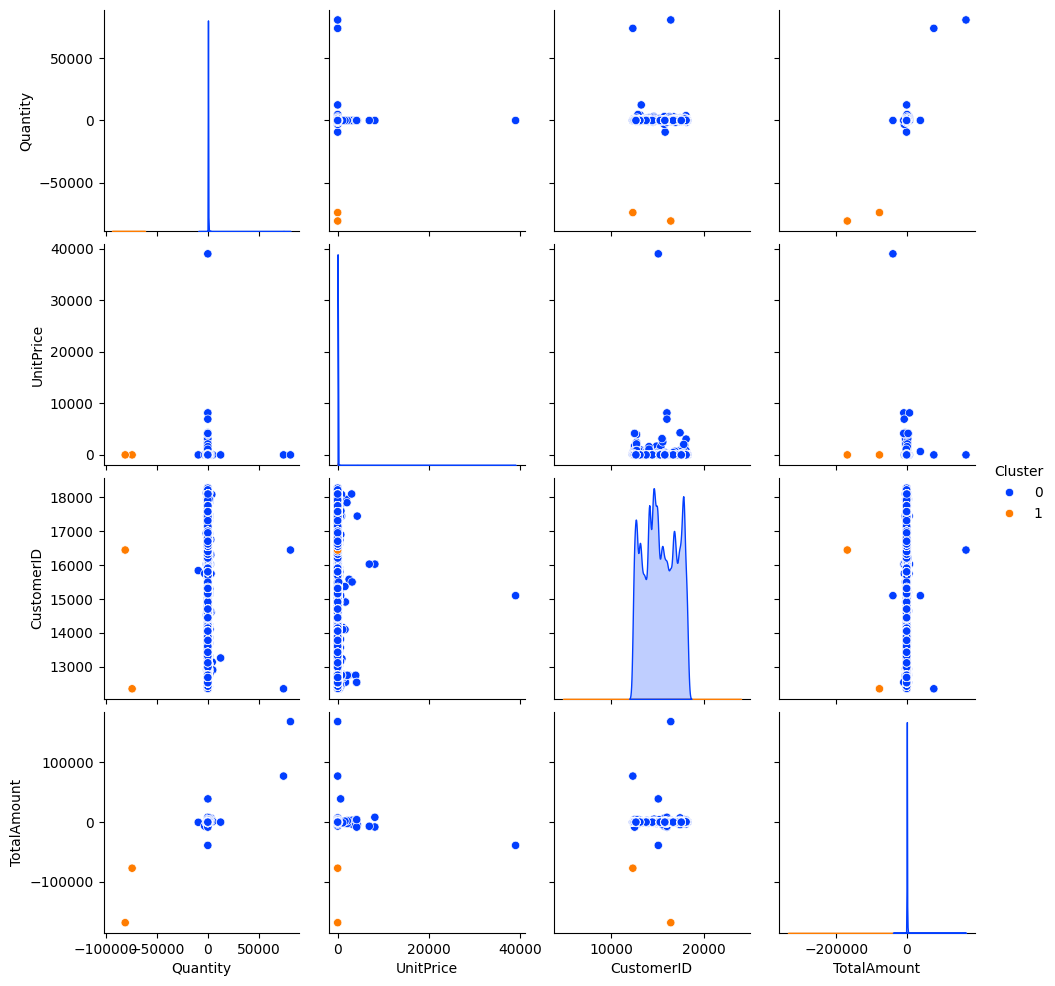

In [46]:
plt.figure(figsize=(20,10))
sns.pairplot(data=df, hue="Cluster", palette="bright")

<a id="5"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> 5.ConcConclusion and Analysis of Customer Segmentationlusion</p>
</div>

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    
 <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>
            The customer segmentation using <b>RFM (Recency & Monetary)</b> with <b>K-Means clustering</b> successfully grouped customers into meaningful segments based on purchase timing and spending behavior.
        </li>
        <li>
            Customers with <b>low Recency</b> and <b>high Monetary</b> represent the most valuable segment and should be prioritized for retention and VIP campaigns.
        </li>
        <li>
            Customers with <b>high Recency</b> and <b>low Monetary</b> are considered <b>inactive / at-risk</b> and can be targeted using re-engagement strategies (discounts, reminders, personalized offers).
        </li>
        <li>
            Moderate segments fall between these extremes and provide opportunities for growth through personalized marketing and upselling strategies.
        </li>
        <li>
            Overall, this segmentation provides actionable insights for improving customer retention, maximizing revenue, and optimizing marketing resources.
        </li>
    </ul>

</div>
